In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics
from google.colab import files
import io

from scipy.signal import find_peaks, peak_prominences, peak_widths
from scipy.integrate import trapezoid
from scipy.optimize import curve_fit

Edit parameters below according to real recording parameters

In [ ]:
fps = 11
DT = 1 / fps

Very important functions. This part (👇) is not supposed to be edited.

In [ ]:
def rolling_window_norm(
    y: pd.Series,
    quant: float,
    wind: int,
    center: bool = True,
    min_periods: int | None = None,
) -> pd.Series:
    """
    Returns a baseline using a centered rolling-quantile baseline. -> the baseline tracks the lower x-th quantile of your trace (robust for big-ish oscillations)
    quant is the quantile for the baseline (between 0 and 1, e.g., 0.1 = 10th percentile).
    wind is the window length (n of timepoints) for the rolling quantile.
    min_periods is the minimum number of recordings in the window (not NaN); defaults to 'wind' (i.e., edges become NaN until the window is full).
    """
    if not (0.0 <= quant <= 1.0):
      raise ValueError("Quantile must be in [0, 1].")

    if min_periods is None:
      min_periods = wind

    # Rolling baseline as lower-envelope tracker (robust to big-ish oscillations)
    return y.rolling(window=wind, center=center, min_periods=min_periods).quantile(quant)

In [ ]:
def smooth_using_gaussian_kernel(
    y: pd.Series | pd.DataFrame,
) -> pd.Series:
    """
    Returns a smoothed version of y, using a Gaussian kernel.
    dt is the time difference between consecutive points in y
    nker is the number of points used to in the kernel
    """
    kernel_sigma = 2
    kernel_width = 5
    return (y.rolling(window=kernel_width, win_type='gaussian', center=True, min_periods=1).mean(std=kernel_sigma))

In [ ]:
def get_peak_positions_and_properties(
    y: pd.Series,
) -> pd.DataFrame:
  v = y.values
  g_med = np.median(v)
  g_mad = np.median(np.abs(v - g_med))
  g_sigma = g_mad * 1.4826 # Conversion factor for Gaussian distribution if noise is Gaussian

  # These values are derived from common usage in similar notebooks
  # and kernel state values (e.g., HEIGHT_SIGMA, PROM_SIGMA)
  MIN_DIST_S = 0.5 # Minimum peak distance in seconds
  HEIGHT_SIGMA = 3.0 # Multiplier for g_sigma to set height threshold
  PROM_SIGMA = 2.0   # Multiplier for g_sigma to set prominence threshold

  min_peak_distance_idx = int(round(MIN_DIST_S / DT))
  height_threshold = g_med + HEIGHT_SIGMA * g_sigma
  prominence_threshold = PROM_SIGMA * g_sigma

  peaks, properties = find_peaks(v, height=height_threshold, prominence=prominence_threshold, distance=min_peak_distance_idx)

  properties["peak_centers_seconds"] = peaks * DT
  properties["peak_centers_idx"] = peaks

  _, _, start_idx, end_idx = peak_widths(v, peaks, rel_height=0.75)
  properties["start_idx"] = start_idx.astype(int)
  properties["end_idx"] = end_idx.astype(int)
  properties["start_seconds"] = start_idx * DT
  properties["end_seconds"] = end_idx * DT

  properties["truncated"] = (properties["start_idx"] == 0) | (properties["end_idx"] == (len(y) - 1))

  # be explicit about which time variables are just indices, and which are in seconds
  #properties["left_bases_idx"] = properties.pop("left_bases")
  #properties["right_bases_idx"] = properties.pop("right_bases")


  # HACK: declare that basis points are width end points
  properties["left_bases_idx"] = properties["start_idx"]
  properties["right_bases_idx"] = properties["end_idx"]

  properties["left_bases_seconds"] = properties["left_bases_idx"] * DT
  properties["right_bases_seconds"] = properties["right_bases_idx"] * DT

  # TODO: add more properties: e.g. widths
  #e.g.

  width_50, _, _, _ = peak_widths(v, peaks, rel_height=0.5)

  properties["width_50_seconds"] = width_50 * DT

  df = pd.DataFrame(properties)
  df.index.name = "spike_index"

  return df

In [ ]:
def get_timeseries_per_spike_df(signal, peaks_and_properties):
  spike_data_list = []

  for idx, spike_props in peaks_and_properties.iterrows():
      # Extract identifiers from MultiIndex
      row_val, col_val, obj_id_val, spike_idx_val = idx

      # Extract spike properties
      left_base = spike_props['left_bases_idx']
      right_base = spike_props['right_bases_idx']
      peak_center = spike_props['peak_centers_idx']

      group_intensity = signal.loc[(row_val, col_val, obj_id_val)]

      # Slice the signal using 0-based indices for the segment
      # right_base is inclusive, so we add 1 to include the last point
      segment_intensity = group_intensity.iloc[left_base : right_base + 1]

      # Calculate 'time from peak'
      # peak_center is an absolute index in the original group_intensity series
      # relative_peak_center is the peak's index within the segment_intensity series
      relative_peak_center = peak_center - left_base
      time_from_peak_array = (np.arange(len(segment_intensity)) - relative_peak_center) * DT

      # Create a temporary DataFrame for this spike segment
      temp_df = pd.DataFrame({
          'Row': row_val,
          'Column': col_val,
          'Object ID': obj_id_val,
          'spike_index': spike_idx_val,
          'time from peak': time_from_peak_array,
          'Intensity': segment_intensity.values
      })

      # Append to the list
      spike_data_list.append(temp_df)

  spike_data_df = pd.concat(spike_data_list, ignore_index=True)
  spike_data_df = spike_data_df.set_index(['Row', 'Column', 'Object ID', 'spike_index', 'time from peak'])

  metadata_to_add = df.groupby(level=['Row', 'Column', 'Object ID'])[['Compound', 'Concentration', 'Cell Type']].first()
  spike_data_df = spike_data_df.merge(
        metadata_to_add,
        left_index=True,
        right_index=True,
        how='left'
  )

  return spike_data_df

In [ ]:
def get_spike_dataframes(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Takes the raw dataframe with Intensity and metadata columns.
    Returns two dataframes with:
      - informations for each spike
      - the full time-series of each spike
    """


    baseline = df["Intensity"].groupby(["Row", "Column", "Object ID"], group_keys=False).apply(
        rolling_window_norm,
        quant = 0.10, #quantile
        wind = 100, #window size
        min_periods = 50 #can be passed to the function, if None, the standard is min_periods = wind
    )

    normalized_value = df["Intensity"] / baseline - 1

    smoothed_normalized = normalized_value.groupby(["Row", "Column", "Object ID"]).apply(
        smooth_using_gaussian_kernel,
        #add other args as needed
    )

    peaks_and_properties = smoothed_normalized.groupby(["Row", "Column", "Object ID"]).apply(
        get_peak_positions_and_properties
    )


    metadata_to_add = df.groupby(level=['Row', 'Column', 'Object ID'])[['Compound', 'Concentration', 'Cell Type']].first()
    peaks_and_properties = peaks_and_properties.merge(
        metadata_to_add,
        left_index=True,
        right_index=True,
        how='left'
    )

    spike_data_df = get_timeseries_per_spike_df(smoothed_normalized, peaks_and_properties)

    return smoothed_normalized, peaks_and_properties, spike_data_df


In [ ]:
def exponential_decay(x, A, k, C):
    return A * np.exp(-k * x) + C

Here we start the analysis.

In [ ]:
# Upload the file
uploaded = files.upload()
exp_file_name = list(uploaded.keys())[0]
print(exp_file_name)

Saving KR253_D65_baseline_LTX1_osci_map_annot.xlsx to KR253_D65_baseline_LTX1_osci_map_annot (3).xlsx
KR253_D65_baseline_LTX1_osci_map_annot (3).xlsx


In [ ]:
# Read a specific sheet from the uploaded Excel file
# Replace 'Sheet1' with the name of the sheet you want to read
df = pd.read_excel(io.BytesIO(uploaded[exp_file_name]), sheet_name="Sheet1") #change sheet number to analyse data from different sheets

# Display column names to help diagnose the KeyError
print("\nDataFrame columns after loading:")
print(df.columns)

# Handle empty concentration columns
df["Concentration"] = df["Concentration"].fillna(0)

# Rename intensity to make things easier
df = df.set_index(["Row", "Column", "Object ID", "Timepoint"])
df = df.rename(columns={"Tracked Loaded Population - Intensity Cell th/Fluo-4 Mean": "Intensity"})

# Sort by time just in case
df = df.sort_values(by="Timepoint", ascending=True)
df.head(5)


DataFrame columns after loading:
Index(['Row', 'Column', 'Timepoint', 'Object ID',
       'Tracked Loaded Population - Intensity Cell th/Fluo-4 Mean',
       'Cell Type', 'Compound', 'Concentration'],
      dtype='object')


Intensity Cell Type Compound  Concentration
Row Column Object ID Timepoint                                             
6   5      1         1            560.070        g2     LTX1            3.0
    4      1         1            515.314        c2     LTX1            3.0
    3      1         1            519.413        g1     LTX1            3.0
    2      1         1            514.044        c1     LTX1            3.0
5   7      1         1            541.000        g3     LTX1            1.0

In [ ]:
## Find peaks, prominence, heigth and witdh
smoothed_normalized, peaks, full_timeseries = get_spike_dataframes(df)

In [ ]:
## Frequency
total_rec_time = smoothed_normalized.groupby(["Row", "Column", "Object ID"]).count() * DT
freq = peaks.groupby(["Row", "Column", "Object ID"]).size() / total_rec_time
freq = freq.rename("Peak Frequency [Hz]")

In [ ]:
## AUC for each spike using trapezoid (non-truncated peaks only)
auc_per_spike = full_timeseries.groupby(level=['Row', 'Column', 'Object ID', 'spike_index']).apply(lambda x: trapezoid(x['Intensity'].values, dx=DT))
auc_per_spike = auc_per_spike.rename('AUC')
auc_per_spike = auc_per_spike[~peaks['truncated']]

auc_per_spike_df = auc_per_spike.to_frame()

In [ ]:
## Wave decay
fitted_params = []

# Group by each spike
grouped_spikes = full_timeseries.groupby(level=['Row', 'Column', 'Object ID', 'spike_index'])

for name, group in grouped_spikes:
    is_truncated = peaks.loc[name]['truncated']
    if is_truncated:
        continue

    # Filter for time from peak >= 0 for decay analysis
    decay_data = group[group.index.get_level_values('time from peak') >= 0]

    xdata = decay_data.index.get_level_values('time from peak').values
    ydata = decay_data['Intensity'].values

    # Initial guess for parameters (A, k, C)
    # C: last intensity value is a reasonable guess for the offset/plateau
    p0_C = ydata[-1]
    # y0: intensity at time from peak = 0 (or first point if xdata does not start at 0)
    # Find the index of xdata where time from peak is exactly 0
    idx_at_zero = np.where(xdata == 0)[0][0]
    p0_y0 = ydata[idx_at_zero]

    # A: Amplitude is initial value minus offset
    p0_A = p0_y0 - p0_C
    # k: decay constant, a small positive number
    p0_k = 1

    # Set bounds for parameters: A > 0, k > 0, C can be any real number
    # Lower bounds: A (0), k (small positive like 1e-6), C (-inf)
    # Upper bounds: A (inf), k (inf), C (inf)
    bounds = ([-np.inf, 1e-6, -np.inf], [np.inf, np.inf, np.inf])

    try:
        params, covariance = curve_fit(exponential_decay, xdata, ydata, p0=[p0_A, p0_k, p0_C], bounds=bounds)
        A, k, C = params

        y_predicted = exponential_decay(xdata, A, k, C)
        mse = np.mean((ydata - y_predicted) ** 2)

        ss_res = np.sum((ydata - y_predicted) ** 2)
        ss_tot = np.sum((ydata - np.mean(ydata)) ** 2)
        r2 = 1 - (ss_res / ss_tot)

        fitted_params.append({
            'Row': name[0],
            'Column': name[1],
            'Object ID': name[2],
            'spike_index': name[3],
            'peak_over_baseline': A,
            'tau': 1 / k,
            'baseline': C,
            "mean_square_error": mse,
            "r2": r2,
        })
    except RuntimeError:
        # Handle cases where curve_fit fails to converge (e.g., 'Optimal parameters not found')
        print(f"Warning: Curve fit failed for spike {name}")
        fitted_params.append({
            'Row': name[0],
            'Column': name[1],
            'Object ID': name[2],
            'spike_index': name[3],
            'peak_over_baseline': np.nan,
            'tau': np.nan,
            'baseline': np.nan,
            "mean_square_error": np.nan,
            "r2": np.nan,
        })


fitted_params_df = pd.DataFrame(fitted_params).set_index(['Row', 'Column', 'Object ID', 'spike_index'])

/tmp/ipython-input-4159364101.py:37: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(exponential_decay, xdata, ydata, p0=[p0_A, p0_k, p0_C], bounds=bounds)


In [ ]:
# Filter interesting data to save
non_truncated_peaks = peaks[~peaks['truncated']]

all_columns = non_truncated_peaks.columns.tolist()


desired_columns = [
    'Cell Type',
    'Compound',
    'Concentration',
    'peak_heights',
    'prominences',
    'peak_centers_seconds',
    'width_50_seconds'
]
non_truncated_peaks = non_truncated_peaks[desired_columns]

non_truncated_peaks.head(5)

Cell Type Compound  Concentration  \
Row Column Object ID spike_index                                     
2   2      1         0                  c1     LTX1            0.0   
           16        0                  c1     LTX1            0.0   
           17        0                  c1     LTX1            0.0   
           19        0                  c1     LTX1            0.0   
                     1                  c1     LTX1            0.0   

                                  peak_heights  prominences  \
Row Column Object ID spike_index                              
2   2      1         0                0.058550     0.058733   
           16        0                0.038352     0.035992   
           17        0                0.061844     0.063346   
           19        0                0.387409     0.392775   
                     1                0.174624     0.125377   

                                  peak_centers_seconds  width_50_seconds  
Row Column Object ID spike_index                                          
2   2      1         0                       23.909091          3.375770  
           16        0                        5.818182          3.118087  
           17        0                        8.363636          3.478111  
           19        0                       18.454545          3.356424  
                     1                       24.636364          3.204219

In [ ]:
## Summary data per spike
# Start with peaks dataframe as the base
summary_data_df = non_truncated_peaks.copy()

# Merge with AUC per spike
summary_data_df = summary_data_df.merge(auc_per_spike, left_index=True, right_index=True, how='left')

# Merge with fitted parameters dataframe
summary_data_df = summary_data_df.merge(fitted_params_df, left_index=True, right_index=True, how='left')
summary_data_df.head(5)


Cell Type Compound  Concentration  \
Row Column Object ID spike_index                                     
2   2      1         0                  c1     LTX1            0.0   
           16        0                  c1     LTX1            0.0   
           17        0                  c1     LTX1            0.0   
           19        0                  c1     LTX1            0.0   
                     1                  c1     LTX1            0.0   

                                  peak_heights  prominences  \
Row Column Object ID spike_index                              
2   2      1         0                0.058550     0.058733   
           16        0                0.038352     0.035992   
           17        0                0.061844     0.063346   
           19        0                0.387409     0.392775   
                     1                0.174624     0.125377   

                                  peak_centers_seconds  width_50_seconds  \
Row Column Object ID spike_index                                           
2   2      1         0                       23.909091          3.375770   
           16        0                        5.818182          3.118087   
           17        0                        8.363636          3.478111   
           19        0                       18.454545          3.356424   
                     1                       24.636364          3.204219   

                                       AUC  peak_over_baseline  tau  baseline  \
Row Column Object ID spike_index                                                
2   2      1         0            0.158272                 NaN  NaN       NaN   
           16        0            0.108595                 NaN  NaN       NaN   
           17        0            0.249608                 NaN  NaN       NaN   
           19        0            1.222454                 NaN  NaN       NaN   
                     1            0.523771                 NaN  NaN       NaN   

                                  mean_square_error  r2  
Row Column Object ID spike_index                         
2   2      1         0                          NaN NaN  
           16        0                          NaN NaN  
           17        0                          NaN NaN  
           19        0                          NaN NaN  
                     1                          NaN NaN

In [ ]:
desired_columns = [
    'Cell Type',
    'Compound',
    'Concentration',
    'peak_heights',
    'prominences',
    'width_50_seconds',
    'AUC',
    'tau',
]
summary_data_df_filtered = summary_data_df[desired_columns]

summary_data_average = summary_data_df_filtered.groupby(["Cell Type", "Compound", "Concentration"]).mean()
summary_data_sem = summary_data_df_filtered.groupby(["Cell Type", "Compound", "Concentration"]).sem()
summary_data_average_df = pd.merge(summary_data_average, summary_data_sem, on=["Compound", "Cell Type", "Concentration"], suffixes=["_mean", "_sem"])

summary_data_average_df.head(5)

peak_heights_mean  prominences_mean  \
Compound Cell Type Concentration                                        
LTX1     c1        0.0                     0.080903          0.071484   
                   0.1                     0.053262          0.031486   
                   0.3                     0.068649          0.036478   
                   1.0                     0.042757          0.037851   
                   3.0                     0.056470          0.048783   

                                  width_50_seconds_mean  AUC_mean   tau_mean  \
Compound Cell Type Concentration                                               
LTX1     c1        0.0                         1.638534  0.176995   2.525110   
                   0.1                         1.166528  0.083963  66.672015   
                   0.3                         1.419841  0.140431   0.232927   
                   1.0                         1.338951  0.115356   0.261262   
                   3.0                         1.207698  0.079922   1.755411   

                                  peak_heights_sem  prominences_sem  \
Compound Cell Type Concentration                                      
LTX1     c1        0.0                    0.018047         0.018381   
                   0.1                    0.004247         0.003728   
                   0.3                         NaN              NaN   
                   1.0                    0.005159         0.006849   
                   3.0                    0.003651         0.004411   

                                  width_50_seconds_sem   AUC_sem    tau_sem  
Compound Cell Type Concentration                                             
LTX1     c1        0.0                        0.261076  0.060810   1.715687  
                   0.1                        0.189278  0.015605  65.339369  
                   0.3                             NaN       NaN        NaN  
                   1.0                        0.554102  0.009130   0.024291  
                   3.0                        0.145266  0.012087   0.523690

In [ ]:
## Average waveforms
average_timeseries = full_timeseries.groupby(["Compound", "Cell Type", "Concentration", "time from peak"]).mean()
sem_timeseries = full_timeseries.groupby(["Compound", "Cell Type", "Concentration", "time from peak"]).sem()
merged_timeseries_df = pd.merge(average_timeseries, sem_timeseries, on=["Compound", "Cell Type", "Concentration", "time from peak"], suffixes=["_mean", "_sem"])

display(merged_timeseries_df.head())

Intensity_mean  Intensity_sem
Compound Cell Type Concentration time from peak                               
LTX1     c1        0.0           -3.818182             0.007397            NaN
                                 -3.727273             0.015408            NaN
                                 -3.636364             0.022185            NaN
                                 -3.545455             0.028185            NaN
                                 -3.454545             0.030937            NaN

In [ ]:
exp_name = exp_file_name #automatically assigns the same name as the excel with the raw data
# Save data to Colab temporarily
summary_df_path = f"{exp_name}_summary_data_per_spike.xlsx"
summary_data_df.to_excel(summary_df_path, index=True)

summary_data_average_df_path = f"{exp_name}_summary_data_average.xlsx"
# Reset index before saving to ensure all index levels become columns and no new index is written
summary_data_average_df.reset_index().to_excel(summary_data_average_df_path, index=False)

merged_timeseries_path = f"{exp_name}_average_waveforms.xlsx"
merged_timeseries_df.to_excel(merged_timeseries_path, index=True) # index=True is default, but explicit for clarity

# Download the files
files.download(summary_df_path)
files.download(summary_data_average_df_path)
files.download(merged_timeseries_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

You can use the block below to plot example traces! :)

/tmp/ipython-input-1636670945.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  sample_peaks_data = peaks.loc[(ROW, COL, OBJ, )] # Get all peak data for this object


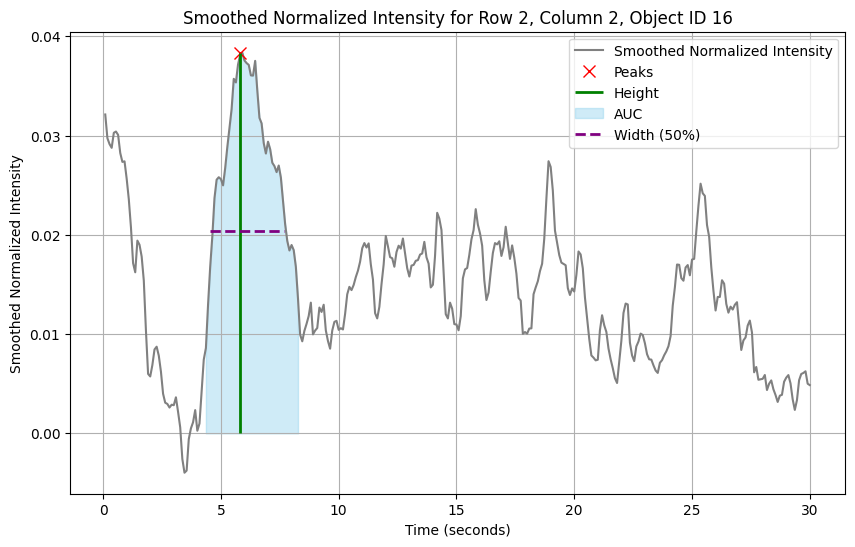

,peak_heights,prominences,left_bases,right_bases,peak_centers_seconds,peak_centers_idx,start_idx,end_idx,start_seconds,end_seconds,truncated,left_bases_idx,right_bases_idx,width_50_seconds,Compound,Concentration,Cell Type
spike_index,,,,,,,,,,,,,,,,,
0,0.038352,0.035992,37,322,5.818182,64,47,90,4.33031,8.237355,False,47,90,3.118087,LTX1,0.0,c1


In [ ]:
ROW = 2
COL = 2
OBJ = 16

sample_trace = smoothed_normalized.loc[(ROW, COL, OBJ)]
sample_peaks_data = peaks.loc[(ROW, COL, OBJ, )] # Get all peak data for this object

plt.figure(figsize=(10, 6)) # Set a larger figure size
plt.plot(sample_trace.index.get_level_values('Timepoint') * DT, sample_trace.values, label='Smoothed Normalized Intensity', color='grey')
plt.title(f'Smoothed Normalized Intensity for Row {ROW}, Column {COL}, Object ID {OBJ}')
plt.xlabel('Time (seconds)')
plt.ylabel('Smoothed Normalized Intensity')
plt.grid(True)

# Add peaks, prominences, and AUC to the plot
if not sample_peaks_data.empty:
    # Get the raw signal values for peak_widths calculation
    v = sample_trace.values
    for i, (peak_index_in_df, peak_info) in enumerate(sample_peaks_data.iterrows()):
        peak_center_idx = peak_info['peak_centers_idx'] # The index of the peak in the original signal
        peak_time = peak_info['peak_centers_seconds']
        peak_height = peak_info['peak_heights']
        prominence = peak_info['prominences']
        left_base_idx = peak_info['left_bases_idx']
        right_base_idx = peak_info['right_bases_idx']

        # Plot 'x' at peak center
        plt.plot(peak_time, peak_height, 'x', color='red', markersize=8, label='Peaks' if i == 0 else "_nolegend_")

        # Plot prominence as a vertical line
        # The line goes from peak_height down by the prominence value
        plt.vlines(x=peak_time, ymin=0, ymax=peak_height, color='green', linestyle='-', linewidth=2, label='Height' if i == 0 else "_nolegend_")

        # Get the time and intensity values for the AUC segment
        auc_x_values = sample_trace.index.get_level_values('Timepoint')[left_base_idx:right_base_idx+1] * DT
        auc_y_values = sample_trace.values[left_base_idx:right_base_idx+1]

        # Fill the area under the curve for this peak
        plt.fill_between(auc_x_values, auc_y_values, color='skyblue', alpha=0.4, label='AUC' if i == 0 else "_nolegend_")

        # Calculate and plot peak width
        # `find_peaks` returns peak indices relative to the input array `v`
        # `peak_widths` also works with these relative indices
        # We need to find the specific peak in `v` that corresponds to `peak_center_idx`

        # Find widths for the single peak using the original signal `v`
        widths, width_heights, left_ips, right_ips = peak_widths(v, [peak_center_idx], rel_height=0.5)

        # `left_ips` and `right_ips` are indices in `v`, convert them to seconds
        left_ips_seconds = left_ips[0] * DT
        right_ips_seconds = right_ips[0] * DT
        width_height = width_heights[0]

        # Plot the horizontal line for the width
        plt.hlines(width_height, left_ips_seconds, right_ips_seconds, color='purple', linestyle='--', linewidth=2, label='Width (50%)' if i == 0 else "_nolegend_")

    plt.legend()
else:
    print(f"No peaks found for Row {ROW}, Column {COL}, Object ID {OBJ} to plot.")

plt.show()
sample_peaks_data